## Preprocessing WSI
To visualise images and annotations consider the ASAP software. 
Furthermore, several packages built upon OpenSlide exist to help WSIs management 
via python. For instance, https://github.com/ysbecca/py-wsi. 

### 1. **Setup ambiente**

In [1]:
# 1. Installa i binari di sistema OpenSlide (obbligatorio per far funzionare la libreria Python)
!apt-get update -y && apt-get install -y openslide-tools

# 2. Installa la libreria Python per interfacciarsi a OpenSlide
!pip install openslide-python

# 3. Installa histolab e tiatoolbox (librerie utilissime per il patching automatico e la rimozione dello sfondo)
!pip install histolab tiatoolbox

# 4. Installa patchify (comoda per dividere le immagini in griglie se decidi di fare un approccio manuale)
!pip install patchify

print("\n--- Setup Completato con Successo! ---")

Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:2 https://cli.github.com/packages stable InRelease [3,917 B]
Get:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease                         
Get:5 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]      
Get:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]           
Get:7 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]        
Get:8 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]      
Get:9 https://cli.github.com/packages stable/main amd64 Packages [354 B]
Get:10 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,703 kB]
Hit:11 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:12 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:13 htt

In [ ]:
import openslide # Solo per controllo interno se serve
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image

print(f"Versione di OpenSlide rilevata nel sistema: {openslide.__version__}")

In [15]:
import os
import glob
from pathlib import Path


DATASET_TRAINING=Path("/kaggle/input/datasets/irenebartolini/cyp11b2-dataset/CASI-CYP11B2-IPERALDO")
DATASET_GT= DATASET_TRAINING / "ground_truth" / "CY"

### 2. **Struttura Piramidale**
Una WSI contiene la stessa immagine salvata a diverse risoluzioni (es. 40x, 20x, 10x, 5x, 1.25x). Il primo obiettivo è caricare l'immagine e leggerne le proprietà.

In [7]:

import openslide
import os

file_he_to_extract = DATASET_TRAINING / "TO26.1_261785_M.58Y_APA-MAPN-MAPM_WS0.__1A.ADR.HE_.ndpi" 
file_cyp_to_extract =  DATASET_TRAINING / "TO26.1_261785_M.58Y_APA-MAPN-MAPM_WS0.__1B.ADR.CYP11B2_.ndpi"

if os.path.exists(file_he_to_extract):
    slide_he = openslide.OpenSlide(file_he_to_extract)
    
    print(f"--- Informazioni File H&E ---")
    print(f"Dimensioni totali (Livello 0): {slide_he.dimensions}")
    print(f"Numero di livelli piramidali: {slide_he.level_count}")
    
    # Stampa le dimensioni di ciascun livello e il relativo fattore di rimpicciolimento
    for i in range(slide_he.level_count):
        print(f"Livello {i} -> Dimensioni: {slide_he.level_dimensions[i]} | Downsample: {slide_he.level_downsamples[i]}")


else:
    print(f"File non trovato al percorso: {file_he_to_extract}")
    
if os.path.exists(file_cyp_to_extract):
    slide_cyp = openslide.OpenSlide(file_cyp_to_extract)
    
    print(f"--- Informazioni File CYP ---")
    print(f"Dimensioni totali (Livello 0): {slide_cyp.dimensions}")
    print(f"Numero di livelli piramidali: {slide_cyp.level_count}")
    
    # Stampa le dimensioni di ciascun livello e il relativo fattore di rimpicciolimento
    for i in range(slide_cyp.level_count):
        print(f"Livello {i} -> Dimensioni: {slide_cyp.level_dimensions[i]} | Downsample: {slide_cyp.level_downsamples[i]}")


else:
    print(f"File non trovato al percorso: {file_cyp_to_extract}")


--- Informazioni File H&E ---
Dimensioni totali (Livello 0): (145920, 92928)
Numero di livelli piramidali: 9
Livello 0 -> Dimensioni: (145920, 92928) | Downsample: 1.0
Livello 1 -> Dimensioni: (72960, 46464) | Downsample: 2.0
Livello 2 -> Dimensioni: (36480, 23232) | Downsample: 4.0
Livello 3 -> Dimensioni: (18240, 11616) | Downsample: 8.0
Livello 4 -> Dimensioni: (9120, 5808) | Downsample: 16.0
Livello 5 -> Dimensioni: (4560, 2904) | Downsample: 32.0
Livello 6 -> Dimensioni: (2280, 1452) | Downsample: 64.0
Livello 7 -> Dimensioni: (1140, 726) | Downsample: 128.0
Livello 8 -> Dimensioni: (570, 363) | Downsample: 256.0
--- Informazioni File CYP ---
Dimensioni totali (Livello 0): (107520, 92928)
Numero di livelli piramidali: 9
Livello 0 -> Dimensioni: (107520, 92928) | Downsample: 1.0
Livello 1 -> Dimensioni: (53760, 46464) | Downsample: 2.0
Livello 2 -> Dimensioni: (26880, 23232) | Downsample: 4.0
Livello 3 -> Dimensioni: (13440, 11616) | Downsample: 8.0
Livello 4 -> Dimensioni: (6720, 

*Spiegazione*
- **Dimensioni totali (Livello 0): (145920, 92928)**
Questo è il livello alla massima risoluzione possibile (lo zoom massimo del microscopio, di solito 20x o 40x).Significa che l'immagine è larga $145.920$ pixel e alta $92.928$ pixel.Se provassi a calcolare i megapixel totali: $145.920 \times 92.928 = 13.559.051.520$ pixel (ovvero circa 13,5 Gigapixel / 13 miliardi di pixel!).

Nel progetto: Questo è il livello su cui dovrai estrarre i patch per addestrare il tuo modello di Machine Learning (U-Net o Feature Extractor), perché contiene i dettagli cellulari necessari per distinguere il tessuto.

- **Numero di livelli piramidali: 9**
Lo scanner ha salvato 9 "versioni" della stessa identica immagine dentro lo stesso file, contrassegnate da un indice che va da 0 a 8.

- **Downsample**:
Il valore di Downsample indica di quante volte l'immagine è stata rimpicciolita rispetto al Livello 0 originale.

Livello 0 (Downsample: 1.0): È l'immagine originale a grandezza naturale.
Livello 2 (Downsample: 4.0): L'immagine è 4 volte più piccola del Livello 0. 

Infatti, se prendi la larghezza originale ($145920$) e la dividi per 4, ottieni esattamente $36480$.Livello 8 (Downsample: 256.0): È la punta della piramide. L'immagine è stata rimpicciolita di 256 volte. Ha una dimensione minuscola ($570 \times 363$ pixel), simile a una normale foto scattata con un vecchio telefono.

### 3. **Visualizzare una "Thumbnail" (Anteprima)**
Dato che l'immagine al Livello 0 è troppo grande per la memoria RAM, per visualizzarla interamente estrarre l'ultimo livello (a minor risoluzione).

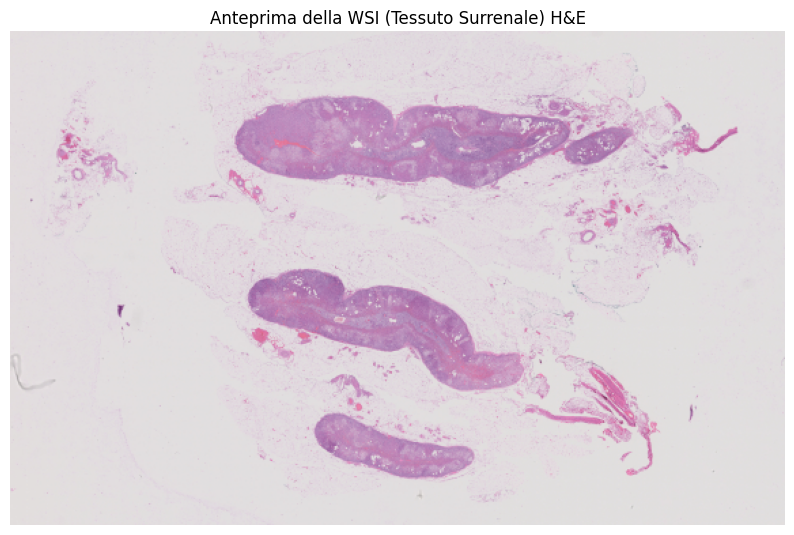

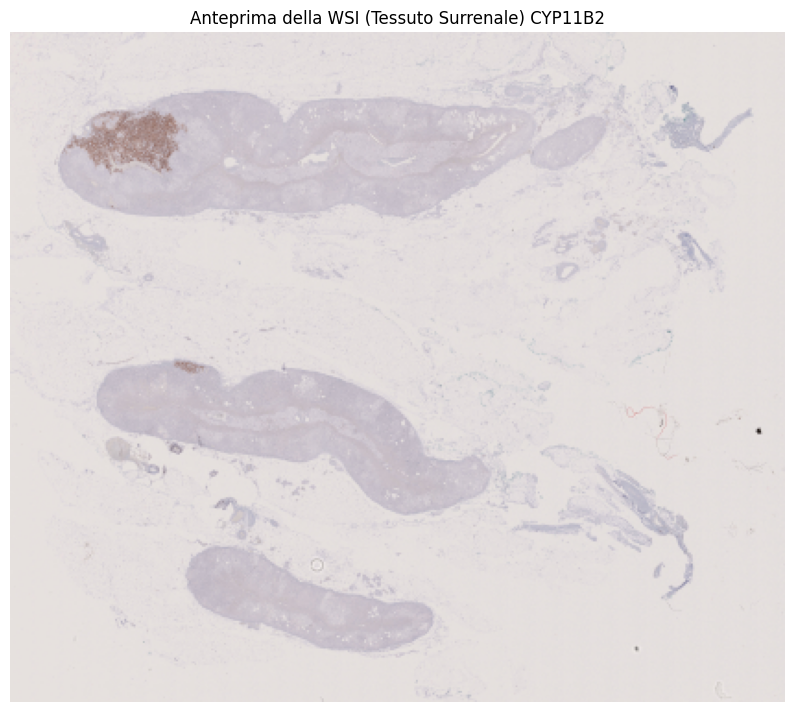

In [8]:
import matplotlib.pyplot as plt

# Estrai una miniatura (thumbnail) specificando la larghezza massima desiderata
thumbnail_he = slide_he.get_thumbnail(size=(570, 363))
thumbnail_cyp = slide_cyp.get_thumbnail(size=(420, 363))


# Mostrala a schermo
plt.figure(figsize=(10, 10))
plt.imshow(thumbnail_he)
plt.title("Anteprima della WSI (Tessuto Surrenale) H&E")
plt.axis('off')
plt.show()

plt.figure(figsize=(10, 10))
plt.imshow(thumbnail_cyp)
plt.title("Anteprima della WSI (Tessuto Surrenale) CYP11B2")
plt.axis('off')
plt.show()

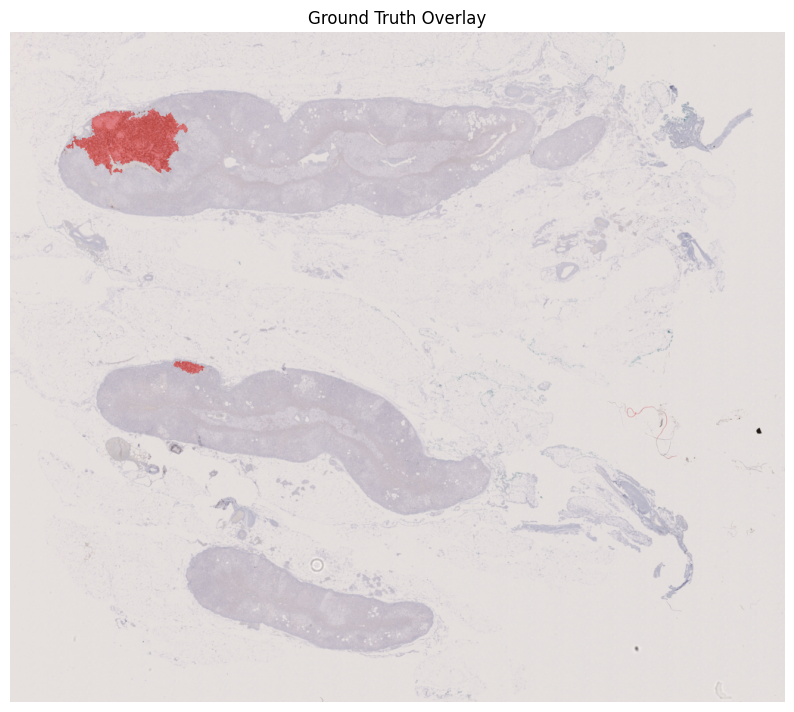

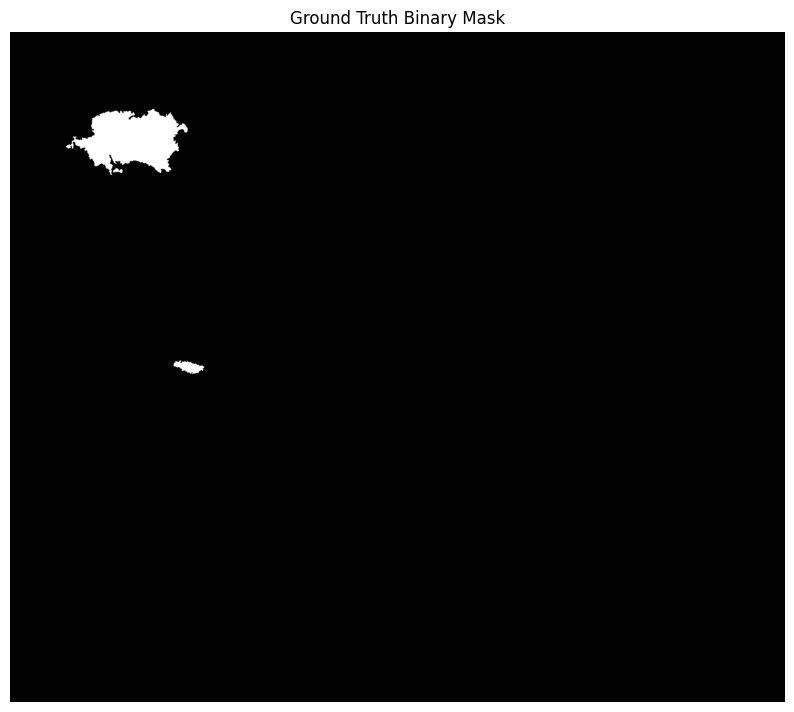

In [16]:
import cv2
import os
import matplotlib.pyplot as plt

## gt 

# "TO26.1_261785_M.58Y_APA-MAPN-MAPM_WS0.__1B.ADR.
gt_path_mask = DATASET_GT / "TO26.1_261785_M.58Y_APA-MAPN-MAPM_WS0.__1B.ADR.CYP11B2__mask.png"
gt_path_overlay = DATASET_GT / "TO26.1_261785_M.58Y_APA-MAPN-MAPM_WS0.__1B.ADR.CYP11B2__overlay.png"

mask = cv2.imread(gt_path_mask)
overlay = cv2.imread(gt_path_overlay)

# --- VISUALIZZAZIONE OVERLAY ---
if overlay is None:
    print(f"ERRORE: Impossibile leggere l'overlay. Verifica il percorso:\n{gt_path_overlay}")
else:
    # Convertiamo da BGR (OpenCV) a RGB (Matplotlib) per vedere il rosso reale
    overlay_rgb = cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)
    
    plt.figure(figsize=(10, 10))
    plt.imshow(overlay_rgb)
    plt.title("Ground Truth Overlay")
    plt.axis('off')
    plt.show()

# --- VISUALIZZAZIONE MASCHERA ---
if mask is None:
    print(f"ERRORE: Impossibile leggere la maschera. Verifica il percorso:\n{gt_path_mask}")
else:
    # Convertiamo in RGB anche la maschera per passarla correttamente a imshow
    mask_rgb = cv2.cvtColor(mask, cv2.COLOR_BGR2RGB)
    
    plt.figure(figsize=(10, 10))
    plt.imshow(mask_rgb)
    plt.title("Ground Truth Binary Mask")
    plt.axis('off')
    plt.show()

## Analisi dei dati forniti 
- quanti pazienti / immagini per paziente
- ground truth corrispondente
- allineamento immagini gt e training set

Controllare per ogni paziente quante e quali immagini abbiamo 

**Filename Convention** 

WSI filenames follow the pattern: 

TO26.1_{PatientID}_M.{AgeGender}_APA-MAPN-MAPM_WS0.__1A.ADR.{Stain}

*Components:*
- TO26.1 → Study / cohort identifier
- {PatientID} → Unique patient identifier (e.g., 261785)
- M.58Y → Gender and age (M = Male, F = Female, 58Y = 58 years old)
- APA-MAPN-MAPM → Histopathological classification (HISTALDO-related, see below)
- WS0.__1A.ADR → Slide / acquisition metadata
- {Stain} → Type of staining:( H&E → Hematoxylin and Eosin, CYP11B2 → Immunohistochemistry staining)


In [80]:
def decript_filename_training ( filename ):
    file_name_parts= filename.split("_")
    # 0 study id
    # 1 patient id
    # 2 patient gender and age
    # 3 Histopathological classification
    # 4 -5 acquisition metadata
    # 6 stain
    # 7 .ndpi
    parts=len(file_name_parts)
    if parts != 8:
        print (f"[WARNING] bad filename {parts} instead of 8")
        print (file_name_parts)
    study_id= file_name_parts[0]
    patient_id= file_name_parts[1]
    patient_gen_and_age= file_name_parts[2]

    patient_gender= patient_gen_and_age.split(".")[0]
    patient_age= patient_gen_and_age.split(".")[1]
    metadata_and_stain=file_name_parts[6]
    metadata_parts= metadata_and_stain.split(".")
    if len(metadata_parts)<3:
        metadata=  metadata_parts[0].replace("ADR", "")
        stain= metadata_parts[1]
    else:
        metadata=  metadata_parts[0]
        stain=  metadata_parts[2]
    # print("\nPatient id: "+ patient_id+ 
    #       "\nGender: "+ patient_gender+
    #       "\nAge: " + patient_age+
    #       "\nStudy ID: "+ study_id +
    #       "\nMetadata: "+ metadata +
    #       "\nStain: "+stain )
    p= {
        'patient_id': patient_id,
        'gender': patient_gender,
        'age': patient_age,
        'study_id': study_id,
        'metadata' : metadata,
        'stain': stain
    }
    return p
    

In [ ]:
def encript_filename_training(obj):
    filename= obj.get("study_id") + "_" + patient_id+"_"+gender+"."+age+"_"+"APA-MAPN-MAPMWS0.__"+
    # due versioni con . e senza 
    filename_1= filename+".ADR."+ stain +"_.ndpi"
    filename_2= filename+"ADR."+ stain +"_.ndpi"
    return filename_1, filename_2

In [120]:
data=[]
patients= []
metadata=[]
number_HE=0
number_CYP=0


file_in_directory = [f.name for f in DATASET_TRAINING.iterdir() if f.is_file()]
for filename in file_in_directory :
    p= decript_filename_training ( filename )
    data.append(p)
    id= p.get("patient_id")
    if id not in patients:
        patients.append(id)
    meta= p.get("metadata")
    if meta not in metadata:
        metadata.append(meta)
    stain= p.get("stain")
    if stain=="HE":
        number_HE+=1
    else:
        number_CYP+=1
    

        
print(f"number of patients {len(patients)}")
print(f"number of HE images {number_HE} , CYO {number_CYP}")

number of patients 2
number of HE images 13 , CYO 13


In [83]:
image_per_patient = [d for d in data if d.get("patient_id") == "261785"]

len(image_per_patient)

20

In [84]:
image_per_patient = [d for d in data if d.get("patient_id") == "265301"]

len(image_per_patient)

6

*Commento*: 
Dall'analisi è emerso che abbiamo dati relativi a **2 pazienti** (261785 e 265301) 
- 20 WSO per 261785 ( 10 HE e 10 CYP)
- 6 WSO per 265301  (3 HE e 3 HE)
  
chiave univoca per identificare una WSO (patient_id, metadata)

In [85]:
import csv

# 1. Definisci il nome del file
nome_file = "/kaggle/working/WSO_metadata.csv"

# 2. Ottieni i nomi delle colonne (gli "header") prendendo le chiavi del primo dizionario
# Assicurati che la lista non sia vuota prima di farlo
if data:
    nomi_colonne = data[0].keys()

    # 3. Apri il file in modalità scrittura ('w'). 
    # 'newline=""' evita righe vuote extra su Windows.
    # 'encoding="utf-8"' garantisce il supporto a caratteri speciali.
    with open(nome_file, mode='w', newline='', encoding='utf-8') as file_csv:
        
        # Crea l'oggetto DictWriter passando il file e le colonne
        writer = csv.DictWriter(file_csv, fieldnames=nomi_colonne)
        
        # Scrive la prima riga con i nomi dei campi (id, age, city)
        writer.writeheader()
        
        # Scrive tutte le righe della lista in un colpo solo
        writer.writerows(data)

    print(f"File '{nome_file}' salvato con successo!")
else:
    print("La lista è vuota, nessun file creato.")

File '/kaggle/working/WSO_metadata.csv' salvato con successo!


### Controllare le GT a cosa corrispondono 

In [90]:
def decript_filename_gt ( filename ):
    file_name_parts= filename.split("_")
    # 0 study id
    # 1 patient id
    # 2 patient gender and age
    # 3 Histopathological classification
    # 4 -5 acquisition metadata
    # 6 stain
    # 
    # 7 .ndpi
    parts=len(file_name_parts)
    if parts != 9:
        print (f"[WARNING] bad filename {parts} instead of 9")
        print (file_name_parts)
    study_id= file_name_parts[0]
    patient_id= file_name_parts[1]
    patient_gen_and_age= file_name_parts[2]

    patient_gender= patient_gen_and_age.split(".")[0]
    patient_age= patient_gen_and_age.split(".")[1]
    metadata_and_stain=file_name_parts[6]
    metadata_parts= metadata_and_stain.split(".")
    
    gt_type= file_name_parts[8].split(".")[0]
    
    if len(metadata_parts)<3:
        metadata=  metadata_parts[0].replace("ADR", "")
        stain= metadata_parts[1]
    else:
        metadata=  metadata_parts[0]
        stain=  metadata_parts[2]
    print("\nPatient id: "+ patient_id+ 
          "\nGender: "+ patient_gender+
          "\nAge: " + patient_age+
          "\nStudy ID: "+ study_id +
          "\nMetadata: "+ metadata +
          "\nStain: "+stain +
          "\nGT type: "+ gt_type)
    p= {
        'patient_id': patient_id,
        'gender': patient_gender,
        'age': patient_age,
        'study_id': study_id,
        'metadata' : metadata,
        'stain': stain,
        'gt_type' : gt_type
    }
    return p
    

In [96]:
data_gt=[]
patients= []
metadata=[]
mask=0
overlay=0



file_in_directory = [f.name for f in DATASET_GT.iterdir() if f.is_file()]
for filename in file_in_directory :
    p= decript_filename_gt ( filename )
    data_gt.append(p)
    id= p.get("patient_id")
    if id not in patients:
        patients.append(id)
    meta= p.get("metadata")
    if meta not in metadata:
        metadata.append(meta)
    if p.get("gt_type")=="mask":
        mask+=1
    elif p.get("gt_type")=="overlay":
        overlay+=1

        
print(f"number of patients {len(patients)}")
print(len(data_gt))
print( f"overlay: {overlay} \nmask: {mask}")


Patient id: 265301
Gender: M
Age: 70Y
Study ID: TO26.2
Metadata: 1B
Stain: CYP11B2
GT type: mask

Patient id: 261785
Gender: M
Age: 58Y
Study ID: TO26.1
Metadata: 6B
Stain: CYP11B2
GT type: overlay

Patient id: 265301
Gender: M
Age: 70Y
Study ID: TO26.2
Metadata: 6B
Stain: CYP11B2
GT type: mask

Patient id: 261785
Gender: M
Age: 58Y
Study ID: TO26.1
Metadata: 9B
Stain: CYP11B2
GT type: mask

Patient id: 261785
Gender: M
Age: 58Y
Study ID: TO26.1
Metadata: 1B
Stain: CYP11B2
GT type: mask

Patient id: 261785
Gender: M
Age: 58Y
Study ID: TO26.1
Metadata: 8B
Stain: CYP11B2
GT type: overlay

Patient id: 261785
Gender: M
Age: 58Y
Study ID: TO26.1
Metadata: 1B
Stain: CYP11B2
GT type: overlay

Patient id: 265301
Gender: M
Age: 70Y
Study ID: TO26.2
Metadata: 2B
Stain: CYP11B2
GT type: mask

Patient id: 261785
Gender: M
Age: 58Y
Study ID: TO26.1
Metadata: 6B
Stain: CYP11B2
GT type: mask

Patient id: 261785
Gender: M
Age: 58Y
Study ID: TO26.1
Metadata: 7B
Stain: CYP11B2
GT type: overlay

Patient

In [117]:
image_per_patient = [d for d in data_gt if d.get("patient_id") == "261785" and d.get("gt_type")=="mask"]
len(image_per_patient)
images=[img.get("metadata") for img in image_per_patient]
images.sort()
print(images)


['10B', '1B', '2B', '3B', '4B', '5B', '6B', '7B', '8B', '9B']


In [118]:

image_per_patient = [d for d in data_gt if d.get("patient_id") == "261785" and d.get("gt_type")=="overlay"]
len(image_per_patient)
images=[img.get("metadata") for img in image_per_patient]
images.sort()
print(images)

['10B', '1B', '2B', '3B', '4B', '5B', '6B', '7B', '8B', '9B']


In [110]:
image_per_patient = [d for d in data_gt if d.get("patient_id") == "265301" and d.get("gt_type")=="mask"]

len(image_per_patient)
print([img.get("metadata") for img in image_per_patient])

['1B', '6B', '2B']


In [119]:
image_per_patient = [d for d in data_gt if d.get("patient_id") == "265301" and d.get("gt_type")=="overlay"]

len(image_per_patient)
print([img.get("metadata") for img in image_per_patient])

['1B', '6B', '2B']


*Commento*: 

le gt in totale sono 26 (13 mask, 13 overlay): 
- 20 per il paziente 261785 (10 mask, 10 overlay delle stesse WSO: ['10B', '1B', '2B', '3B', '4B', '5B', '6B', '7B', '8B', '9B']) 
- 6 per il paziente "265301" (3 mask, 3 overlay delle stesse WSO: ['1B', '6B', '2B'])

Il prossimo passo è generare allineare le immagini del training set (estrarre i patch corrispondenti) alle ground truth 

### 4. **Rilevamento del Tessuto (Tissue Masking)**
Le WSI contengono moltissimo "spazio bianco" (il vuoto intorno al pezzetto di tessuto sul vetrino). Elaborare i patch bianchi è uno spreco di tempo e risorse computazionali. E' necessario creare una maschera che identifichi solo il tessuto.

Converto l'anteprima in scala di grigi o nello spazio colore HSV e applicando una soglia (Otsu Thresholding):

In [ ]:
# import cv2
# import numpy as np

# # Converti la miniatura in array numpy
# img_np = np.array(thumbnail)

# # Passa a scala di grigi e applica un filtro Gaussiano per ridurre il rumore
# gray = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)
# blurred = cv2.GaussianBlur(gray, (5, 5), 0)

# # Soglia di Otsu per separare tessuto (scuro) dallo sfondo (bianco brillante)
# _, tissue_mask = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# # Visualizza il risultato
# plt.imshow(tissue_mask, cmap='gray')
# plt.title("Maschera del Tessuto (In bianco le aree da analizzare)")
# plt.show()

# 5. **Logica del Patching**
Una volta isolato il tessuto, estrarre i patch alla massima risoluzione (Livello 0) solo dalle zone in cui la maschera è positiva. Scegliamo la dimensione del patch (es. $256 \times 256$ o $512 \times 512$ pixel). 


**NOTA**: Le WSI occupano tantissimo spazio.  l'ambiente Kaggle ha un limite di spazio sul disco locale (20GB per l'output).

**Non salvare i patch come singole immagini** .png o .jpg sul disco di Kaggle, per non esaurire la memoria (Disk quota exceeded).

Strategia migliore: **Estrai i patch "al volo" (on-the-fly) mentre addestri il modello usando un Dataset custom di PyTorch**.

In [ ]:
# Esempio per estrarre un singolo patch a coordinate specifiche
# x_coord = 5000  # Coordinate riferite sempre al livello 0 (massima risoluzione)
# y_coord = 8000
# patch_size = (256, 256)
# target_level = 0

# # Leggi la regione
# patch = slide.read_region((x_coord, y_coord), target_level, patch_size)
# # Nota: read_region restituisce un'immagine RGBA, convertila in RGB
# patch = patch.convert("RGB")

# plt.imshow(patch)
# plt.axis('off')
# plt.show()